# Logistic Regression for Calendar Labeling

Goal: predict each calendar event label (`academic`, `professional`, `personal`) from text features.


## 1) Imports

This section imports libraries for preprocessing, modeling, and evaluation.


In [21]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


## 2) Load and Clean Data

This section loads the labeled dataset, sets a random seed, shuffles rows, and applies basic text/label cleaning.


In [22]:
# -----------------------------
# 1) Load and prepare the data
# -----------------------------

# Fixed seed for reproducibility (same idea used in your Naive Bayes notebook)
RANDOM_SEED = 42

# Load labeled data
# Note: This file should have at least columns: summary, Label
df = pd.read_excel(r"C:/Users/Mr. Paul/Downloads/CS156 Assignment/Data_Labeled.xlsx")

# Randomize row order first because events are semi-ordered by time
# This prevents accidental temporal ordering effects in train/test split
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Keep only the columns needed for this baseline classifier
df = df[["summary", "Label"]].copy()

# Basic cleaning
# - Fill missing summaries with empty string
# - Force text type
# - Strip label spacing
# - Drop rows with missing labels
df["summary"] = df["summary"].fillna("").astype(str)
df["Label"] = df["Label"].astype(str).str.strip()
df = df[df["Label"] != ""]

print(f"RANDOM_SEED = {RANDOM_SEED}")
print("Dataset shape:", df.shape)
print("Class distribution:")
print(df["Label"].value_counts())


RANDOM_SEED = 42
Dataset shape: (1228, 2)
Class distribution:
Label
professional    631
academic        303
personal        294
Name: count, dtype: int64


## 3) Train/Test Split

This section creates a stratified 80/20 split so class proportions are preserved.


In [23]:
# -------------------------------------------
# 2) Train/test split (stratified by class)
# -------------------------------------------

X_text = df["summary"]
y = df["Label"]

# Stratify keeps class proportions similar in train and test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Train rows:", len(X_train_text))
print("Test rows:", len(X_test_text))
print()
print("Train class distribution:")
print(y_train.value_counts())


Train rows: 982
Test rows: 246

Train class distribution:
Label
professional    505
academic        242
personal        235
Name: count, dtype: int64


## 4) Text Vectorization (TF-IDF)

This section fits TF-IDF on training text only and transforms both train and test sets.


In [24]:
# ---------------------------------
# 3) Convert text to TF-IDF vectors
# ---------------------------------

# Fit vectorizer ONLY on training text to avoid leakage
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),  # use unigrams + bigrams
    min_df=2,
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print("X_train_vec shape:", X_train_vec.shape)
print("X_test_vec shape:", X_test_vec.shape)


X_train_vec shape: (982, 803)
X_test_vec shape: (246, 803)


## 5) Train Logistic Regression

Baseline logistic model with class balancing and sufficient iterations for convergence.


In [25]:
# ------------------------------------------
# 4) Train logistic regression
# ------------------------------------------

# class_weight='balanced' helps reduce bias from class imbalance
# max_iter increased to ensure convergence on sparse text features
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_SEED,
)

log_reg.fit(X_train_vec, y_train)
print("Model training complete.")


Model training complete.


## 6) Baseline Evaluation

This section reports test accuracy, Macro-F1, Weighted-F1, confusion matrix, and classification report.


Test Accuracy   : 0.9146
Test Macro F1   : 0.9033
Test Weighted F1: 0.9131


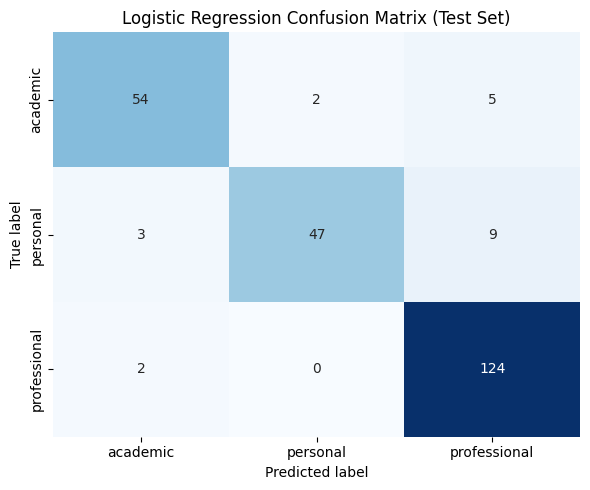


Classification Report (Test Set):
              precision    recall  f1-score   support

    academic       0.92      0.89      0.90        61
    personal       0.96      0.80      0.87        59
professional       0.90      0.98      0.94       126

    accuracy                           0.91       246
   macro avg       0.92      0.89      0.90       246
weighted avg       0.92      0.91      0.91       246



In [26]:
# -----------------------------
# 5) Evaluate on TEST set only
# -----------------------------

y_pred = log_reg.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Test Accuracy   : {acc:.4f}")
print(f"Test Macro F1   : {macro_f1:.4f}")
print(f"Test Weighted F1: {weighted_f1:.4f}")

label_order = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.title("Logistic Regression Confusion Matrix (Test Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, labels=label_order))




## 7) Coefficient Interpretation

This section shows the highest positive token coefficients for each class.


In [27]:
# ----------------------------------------------------
# 6) Inspect top tokens that drive each class decision
# ----------------------------------------------------

# Logistic regression stores one coefficient per class per token.
# Larger positive coefficient => token pushes prediction toward that class.

feature_names = np.array(vectorizer.get_feature_names_out())

# coef_ shape: (n_classes, n_features)
for class_index, class_name in enumerate(log_reg.classes_):
    coefs = log_reg.coef_[class_index]
    top_idx = np.argsort(coefs)[-15:][::-1]

    print()
    print(f"Class: {class_name}")
    for idx in top_idx:
        print(f"  {feature_names[idx]:<30} coef={coefs[idx]:.4f}")



Class: academic
  ccp                            coef=2.2325
  session                        coef=1.9982
  assignment                     coef=1.9800
  cs142                          coef=1.4965
  assignment deadline            coef=1.4535
  deadline                       coef=1.4535
  meeting                        coef=1.3840
  ws                             coef=1.1925
  capstone                       coef=1.1376
  carl neha                      coef=1.1282
  neha                           coef=1.1282
  cs152                          coef=1.1104
  ws meeting                     coef=1.0914
  lba                            coef=1.0913
  cp191                          coef=1.0677

Class: personal
  jiyun                          coef=2.0458
  stay                           coef=1.9851
  checkout                       coef=1.9069
  minervacapella                 coef=1.8373
  room                           coef=1.7373
  flight                         coef=1.6646
  quiet              

## 8) Hyperparameter Tuning: C

This section sweeps `C` values and ranks models by Macro-F1.


In [28]:
# Hyperparameter tuning: C (regularization strength)
from sklearn.metrics import accuracy_score, f1_score

c_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]
c_results = []

for c in c_values:
    model_c = LogisticRegression(
        C=c,
        max_iter=3000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_SEED
    )

    model_c.fit(X_train_vec, y_train)
    y_pred_c = model_c.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred_c)
    macro_f1 = f1_score(y_test, y_pred_c, average='macro')
    weighted_f1 = f1_score(y_test, y_pred_c, average='weighted')

    c_results.append({
        'C': c,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    })

c_results_df = pd.DataFrame(c_results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(c_results_df)

best_row = c_results_df.iloc[0]
print(
    f"Best C by Macro-F1: {best_row['C']} | "
    f"Macro-F1={best_row['macro_f1']:.4f}, Accuracy={best_row['accuracy']:.4f}, "
    f"Weighted-F1={best_row['weighted_f1']:.4f}"
)


,C,accuracy,macro_f1,weighted_f1
0,50.00,0.922764,0.917020,0.922583
1,100.00,0.922764,0.917020,0.922583
2,200.00,0.922764,0.917020,0.922583
3,20.00,0.922764,0.917020,0.922583
4,10.00,0.922764,0.914490,0.922774
5,5.00,0.922764,0.913429,0.921531
6,2.00,0.918699,0.907900,0.917386
7,1.00,0.914634,0.903255,0.913071
8,0.50,0.914634,0.901966,0.913056
9,0.10,0.886179,0.870881,0.884960


Best C by Macro-F1: 50.0 | Macro-F1=0.9170, Accuracy=0.9228, Weighted-F1=0.9226


## 9) Best-Model Comparison (Logistic vs Naive Bayes)

This section compares:
- Logistic Regression (`C=20`)
- Naive Bayes (`alpha=0.01`)

Both are tested on the same seed/split and plotted side by side.


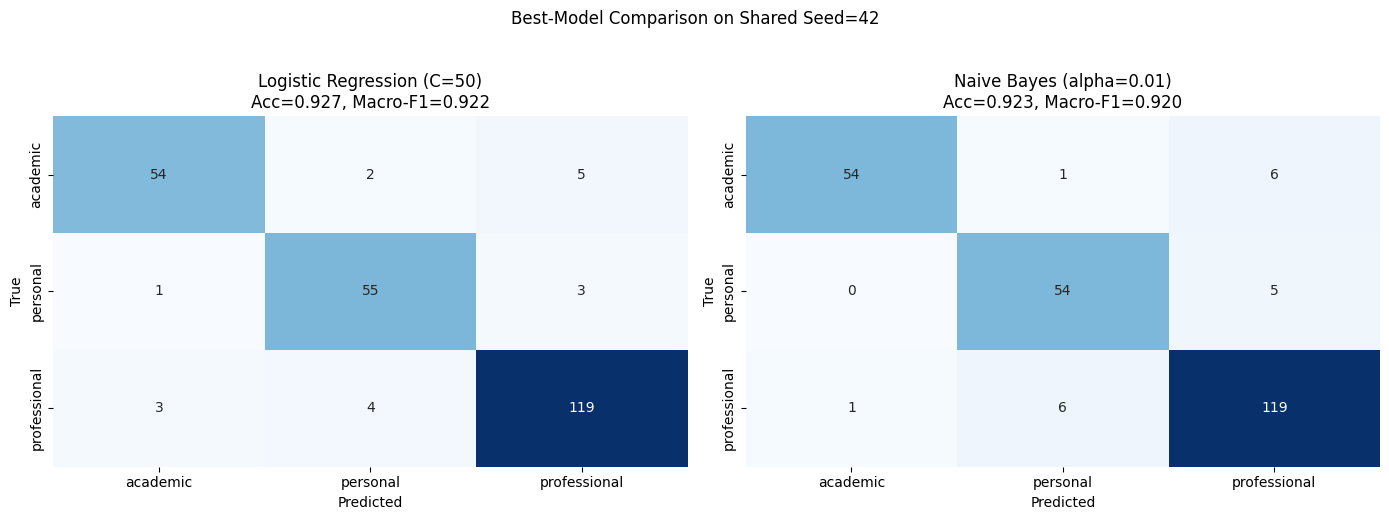

,model,accuracy,macro_f1
0,Logistic Regression (C=50),0.926829,0.921647
1,Naive Bayes (alpha=0.01),0.922764,0.920241


In [29]:
# Side-by-side comparison on the same seed/split
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

COMPARE_SEED = RANDOM_SEED
TEST_SIZE = 0.2

# Rebuild a shared split to guarantee fairness
work_df = df[["summary", "Label"]].copy()
work_df["summary"] = work_df["summary"].fillna("").astype(str)
work_df["Label"] = work_df["Label"].astype(str).str.strip()
work_df = work_df[work_df["Label"] != ""]
work_df = work_df.sample(frac=1, random_state=COMPARE_SEED).reset_index(drop=True)

X_text_cmp = work_df["summary"]
y_cmp = work_df["Label"]
X_train_text_cmp, X_test_text_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X_text_cmp, y_cmp,
    test_size=TEST_SIZE,
    random_state=COMPARE_SEED,
    stratify=y_cmp
)

# Shared vectorizer for both models
vec_cmp = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2)
X_train_cmp = vec_cmp.fit_transform(X_train_text_cmp)
X_test_cmp = vec_cmp.transform(X_test_text_cmp)
label_order = sorted(y_test_cmp.unique())

# Best Logistic Regression model
lr_best = LogisticRegression(
    C=50.0,
    max_iter=3000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=COMPARE_SEED
)
lr_best.fit(X_train_cmp, y_train_cmp)
y_pred_lr = lr_best.predict(X_test_cmp)

# Best Naive Bayes model (custom implementation)
class MyMultinomialNBCompare:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]
        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[(y == c)]
            self.class_log_prior_[idx] = np.log(X_c.shape[0] / X.shape[0])
            feature_sum = X_c.sum(axis=0).A1
            smoothed = feature_sum + self.alpha
            denom = feature_sum.sum() + self.alpha * n_features
            self.feature_log_prob_[idx, :] = np.log(smoothed / denom)
        return self

    def predict(self, X):
        log_probs = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.argmax(log_probs, axis=1)]

nb_best = MyMultinomialNBCompare(alpha=0.01)
nb_best.fit(X_train_cmp, y_train_cmp)
y_pred_nb = nb_best.predict(X_test_cmp)

# Metrics
lr_acc = accuracy_score(y_test_cmp, y_pred_lr)
lr_f1 = f1_score(y_test_cmp, y_pred_lr, average="macro")
nb_acc = accuracy_score(y_test_cmp, y_pred_nb)
nb_f1 = f1_score(y_test_cmp, y_pred_nb, average="macro")

cm_lr = confusion_matrix(y_test_cmp, y_pred_lr, labels=label_order)
cm_nb = confusion_matrix(y_test_cmp, y_pred_nb, labels=label_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title(f"Logistic Regression (C=50)\nAcc={lr_acc:.3f}, Macro-F1={lr_f1:.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=label_order, yticklabels=label_order, ax=axes[1])
axes[1].set_title(f"Naive Bayes (alpha=0.01)\nAcc={nb_acc:.3f}, Macro-F1={nb_f1:.3f}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.suptitle(f"Best-Model Comparison on Shared Seed={COMPARE_SEED}", y=1.03)
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([
    {"model": "Logistic Regression (C=50)", "accuracy": lr_acc, "macro_f1": lr_f1},
    {"model": "Naive Bayes (alpha=0.01)", "accuracy": nb_acc, "macro_f1": nb_f1},
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(comparison_df)
